In [48]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [49]:
!make

make: Nothing to be done for `all'.


In [50]:
def run_test(test_name,n_runs = 200,n_elems = 16000,n_threads = 1):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $threads
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [51]:
def multi_plot(data_deque, data_syncro, title):

    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    ticks = []

    for i in range(0,len(data_deque)):
        boxes.append(data_deque[i])
        boxes.append(data_syncro[i])
        colors.append("peachpuff")
        colors.append("orange")
        ticks.append(str(n_threads[i]))
        ticks.append(str(n_threads[i]))

    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)
    # Etichette per gli assi
    ax.set_xticks([1,2,3,4,5,6,7,8],ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.legend([bplot["boxes"][0], bplot["boxes"][1]], ['deque', 'syncro_queue'], loc='upper left')

    for median in bplot['medians']:
        median.set_color('red')

    plt.show()

In [52]:
def plot(data_deque, data_syncro, title):

    fig, ax = plt.subplots()

    ax.boxplot([data_deque[0],data_syncro[0]], positions=[1,2], showfliers = False)
    # Etichette per gli assi
    ax.set_xticks([1,2],["Deque","Worker_queue"])
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    plt.show()


# Set number of runs

In [53]:
n_runs = 200

# Set number of threads

In [54]:
n_threads = [2,4,6,8]

# Set number of elements

In [55]:
n_elems = 16000

# Single threaded tests

## Pop back

In [56]:
test_worker_queue_pop_back = run_test("test_worker_queue_pop_back",n_runs,n_elems)
test_deque_pop_back = run_test("test_deque_pop_back",n_runs,n_elems)

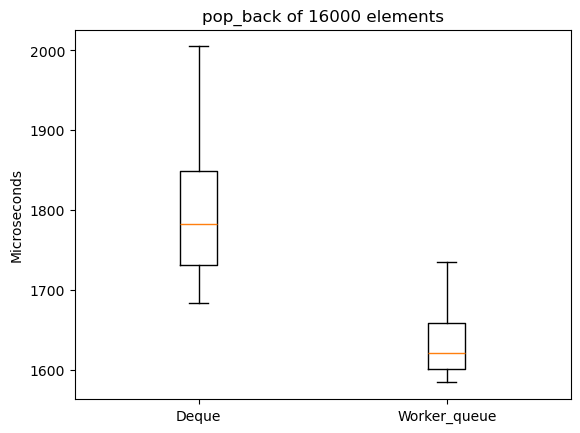

In [57]:
plot(test_deque_pop_back, test_worker_queue_pop_back,"pop_back of "+str(n_elems)+" elements")

## Pop front

In [58]:
test_worker_queue_pop_front = run_test("test_worker_queue_pop_front",n_runs,n_elems)
test_deque_pop_front = run_test("test_deque_pop_front",n_runs,n_elems)

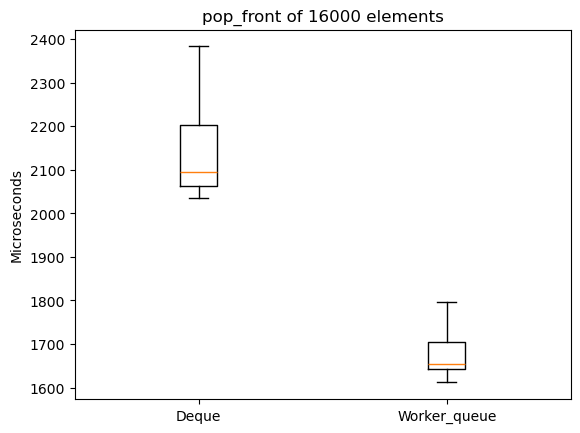

In [59]:
plot(test_deque_pop_front, test_worker_queue_pop_front,"pop_front of "+str(n_elems)+" elements")

## Push back

In [60]:
test_worker_queue_push_back = run_test("test_worker_queue_push_back",n_runs,n_elems)
test_deque_push_back = run_test("test_deque_push_back",n_runs,n_elems)

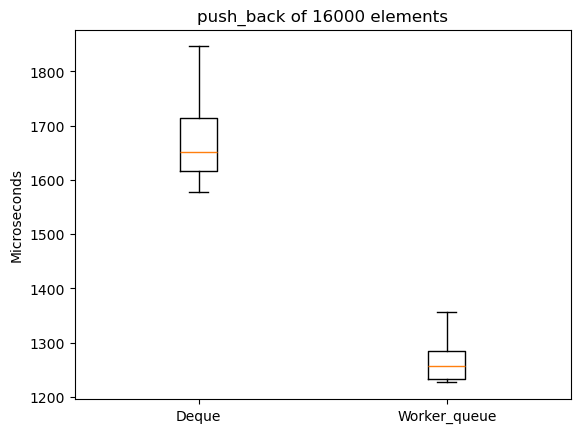

In [61]:
plot(test_deque_push_back, test_worker_queue_push_back,"push_back of "+str(n_elems)+" elements")

## Push front

In [62]:
test_worker_queue_push_front = run_test("test_worker_queue_push_front",n_runs,n_elems)
test_deque_push_front = run_test("test_deque_push_front",n_runs,n_elems)

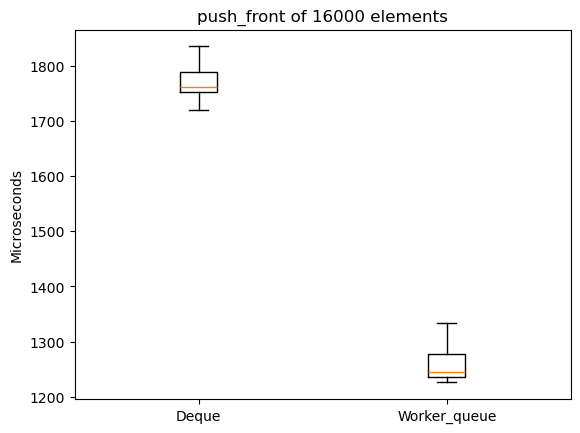

In [63]:
plot(test_deque_push_front, test_worker_queue_push_front,"push_front of "+str(n_elems)+" elements")

# Multithreaded tests

## Pop back

In [64]:
test_deque = run_test("test_deque_pop_back_multi",n_runs,n_elems,n_threads)
test_worker_queue = run_test("test_worker_queue_pop_back_multi",n_runs,n_elems,n_threads)

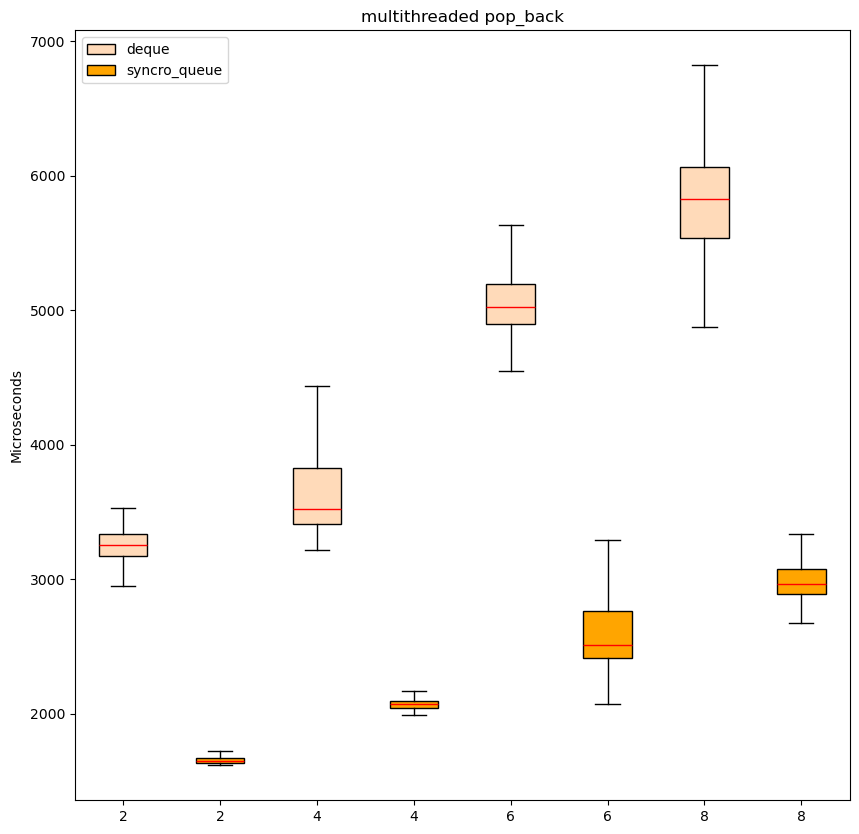

In [65]:
multi_plot(test_deque,test_worker_queue,"multithreaded pop_back")


## Pop front

In [66]:
test_deque = run_test("test_deque_pop_front_multi",n_runs,n_elems,n_threads)
test_worker_queue = run_test("test_worker_queue_pop_front_multi",n_runs,n_elems,n_threads)

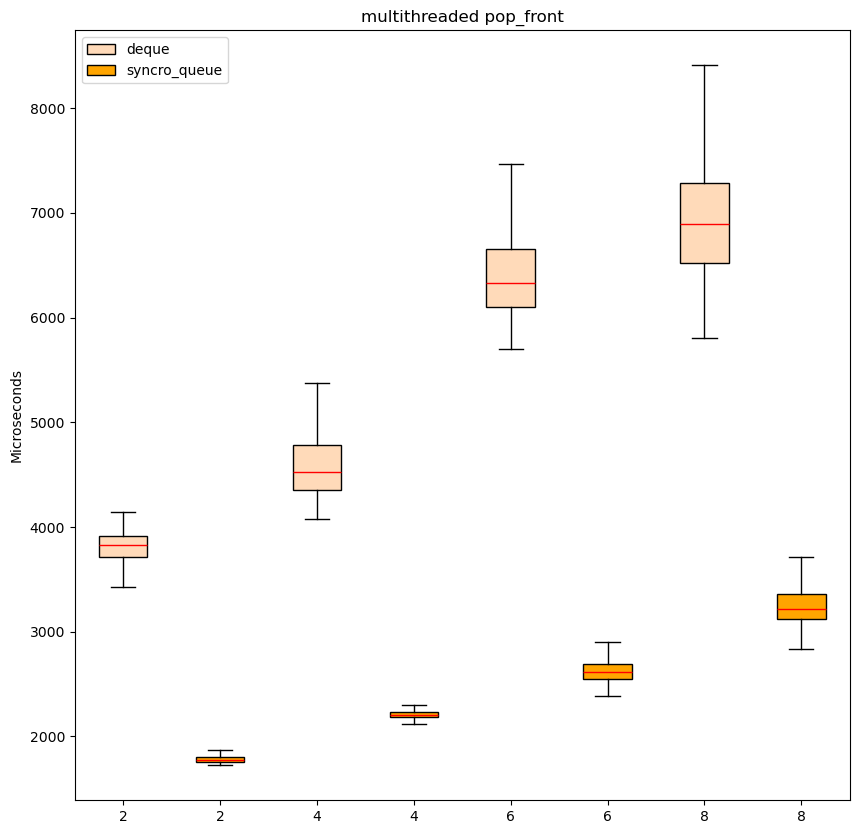

In [67]:
multi_plot(test_deque,test_worker_queue,"multithreaded pop_front")

## Push back

In [68]:
test_deque = run_test("test_deque_push_back_multi",n_runs,n_elems,n_threads)
test_worker_queue = run_test("test_worker_queue_push_back_multi",n_runs,n_elems,n_threads)

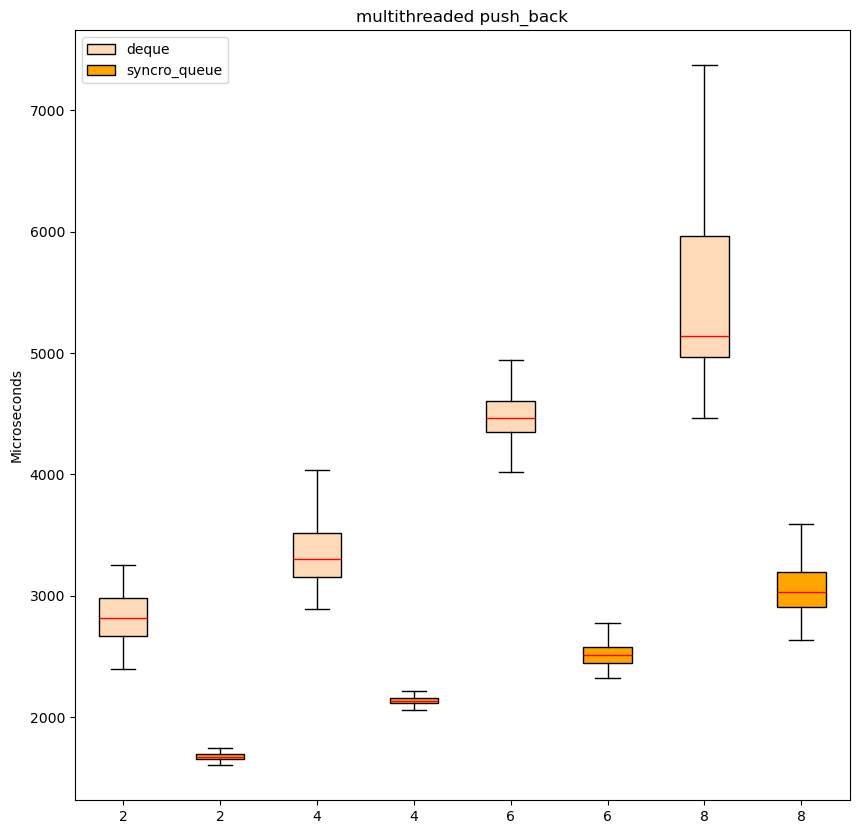

In [69]:
multi_plot(test_deque,test_worker_queue,"multithreaded push_back")

## Push front

In [70]:
test_deque = run_test("test_deque_push_front_multi",n_runs,n_elems,n_threads)
test_worker_queue = run_test("test_worker_queue_push_front_multi",n_runs,n_elems,n_threads)

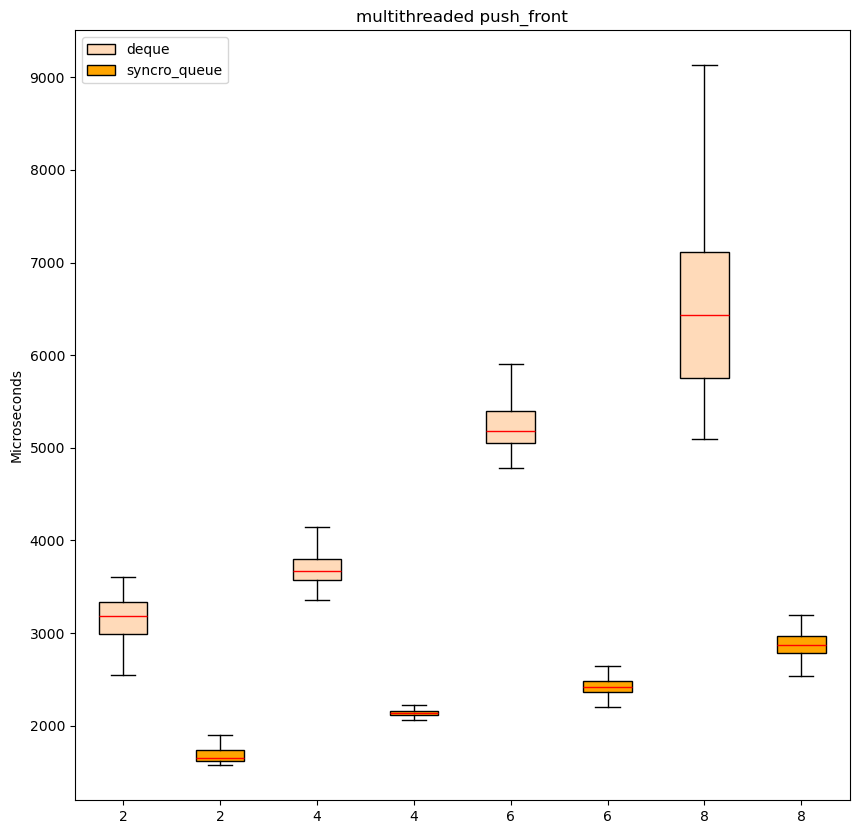

In [71]:
multi_plot(test_deque,test_worker_queue,"multithreaded push_front")